<a href="https://colab.research.google.com/github/nastena-gif-rich/-/blob/master/%D0%94%D0%BE%D0%B1%D1%80%D0%BE_%D0%BF%D0%BE%D0%B6%D0%B0%D0%BB%D0%BE%D0%B2%D0%B0%D1%82%D1%8C_%D0%B2_Colab!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--2026-06-28 15:24:59--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  58.89K  --.-KB/s    in 0.04s   

2026-06-28 15:24:59 (1.44 MB/s) - ‘train.csv’ saved [60302/60302]

✅ Данные загружены! Размер: (891, 12)
✅ Данные обработаны! Колонок: 11
✅ Признаков (X): 10
✅ Целей (y): 891

🖼️ Строим графики...


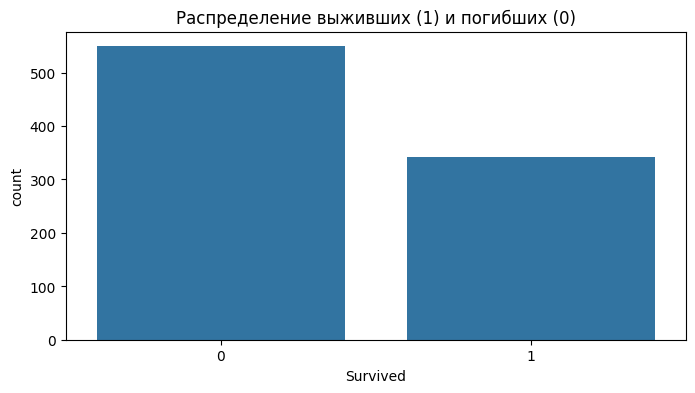

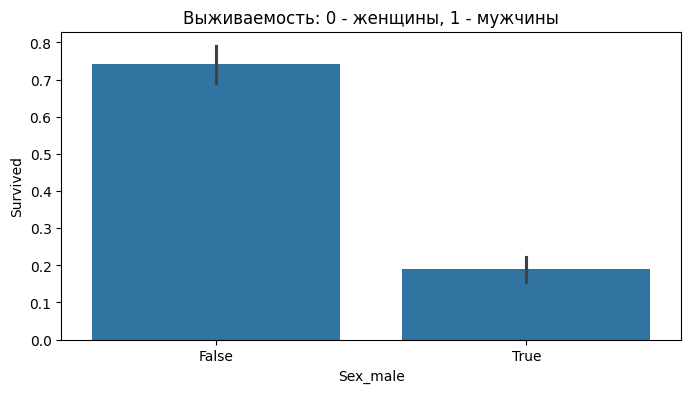

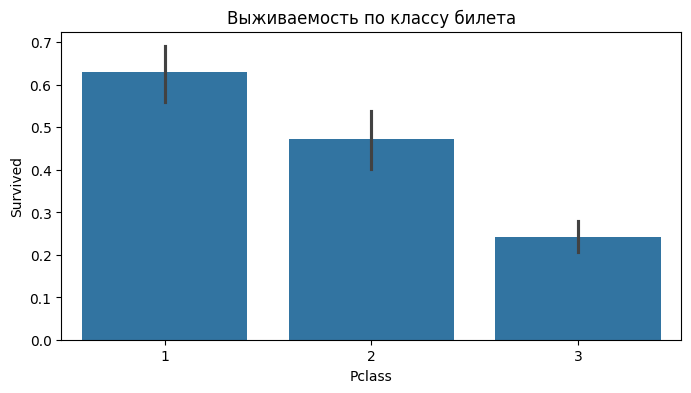

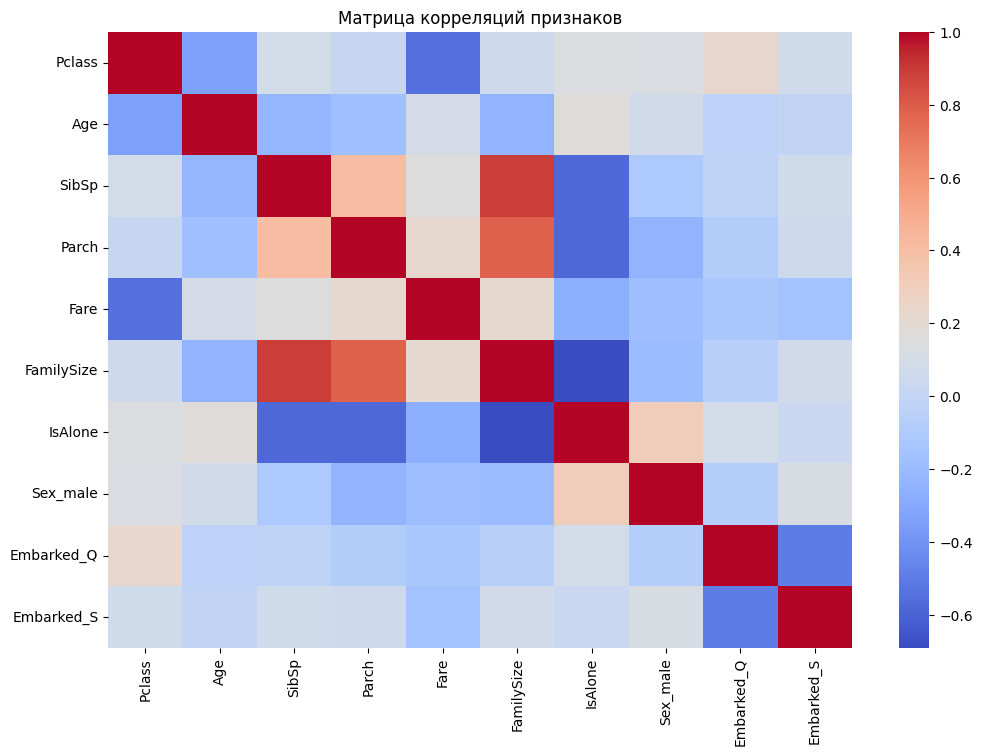

✅ Графики построены!
✅ Обучающая выборка: 712 пассажиров
✅ Проверочная выборка: 179 пассажиров

⚔️ НАЧИНАЕМ БИТВУ АЛГОРИТМОВ!

🔄 Обучаю: Логистическая регрессия...
   ✅ Точность: 0.7989, ROC-AUC: 0.8869

🔄 Обучаю: KNN (ближайшие соседи)...
   ✅ Точность: 0.7039, ROC-AUC: 0.7772

🔄 Обучаю: Дерево решений...
   ✅ Точность: 0.7877, ROC-AUC: 0.8093

🔄 Обучаю: Случайный лес...


INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:43493
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:38717/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.scheduler:Receive client connection: Client-876583ee-7305-11f1-808b-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:38890


   ✅ Точность: 0.8156, ROC-AUC: 0.8900

🔄 Обучаю: SVM...
   ✅ Точность: 0.8156, ROC-AUC: 0.8375


📊 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ:
                 Модель  Точность  ROC-AUC
                    SVM    0.8156   0.8375
          Случайный лес    0.8156   0.8900
Логистическая регрессия    0.7989   0.8869
         Дерево решений    0.7877   0.8093
 KNN (ближайшие соседи)    0.7039   0.7772

🤖 ЗАПУСКАЕМ AUTOML (TPOT)... ЭТО ЗАЙМЁТ 3-5 МИНУТ!
⏳ Не пугайся, если бегают строчки — это нормально



ERROR:distributed.core:Exception while handling op scatter
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/distributed/core.py", line 798, in _handle_comm
    result = await result
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/distributed/scheduler.py", line 6361, in scatter
    raise TimeoutError("No valid workers found")
TimeoutError: No valid workers found


TimeoutError: No valid workers found

In [6]:
# =====================================================
# 1. УСТАНОВКА БИБЛИОТЕК
# =====================================================
!pip install tpot

# =====================================================
# 2. ЗАГРУЗКА ДАННЫХ
# =====================================================
!wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv -O train.csv

# =====================================================
# 3. ИМПОРТ БИБЛИОТЕК
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score
from tpot import TPOTClassifier
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# 4. ЗАГРУЗКА ДАННЫХ В ПЕРЕМЕННУЮ
# =====================================================
df = pd.read_csv('train.csv')
print("✅ Данные загружены! Размер:", df.shape)

# =====================================================
# 5. ПРЕДОБРАБОТКА ДАННЫХ
# =====================================================
def preprocess(data):
    df_clean = data.copy()

    # Удаляем ненужные колонки
    df_clean = df_clean.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

    # Заполняем пропуски
    df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
    df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
    df_clean['Fare'] = df_clean['Fare'].fillna(df_clean['Fare'].median())

    # Создаём новые признаки
    df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
    df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

    # Превращаем текст в цифры
    df_clean = pd.get_dummies(df_clean, columns=['Sex', 'Embarked'], drop_first=True)

    return df_clean

df_processed = preprocess(df)
print("✅ Данные обработаны! Колонок:", df_processed.shape[1])

# =====================================================
# 6. ОТДЕЛЯЕМ ЦЕЛЕВУЮ ПЕРЕМЕННУЮ
# =====================================================
y = df_processed['Survived']
X = df_processed.drop('Survived', axis=1)

print("✅ Признаков (X):", X.shape[1])
print("✅ Целей (y):", y.shape[0])

# =====================================================
# 7. ГРАФИКИ (EDA)
# =====================================================
print("\n🖼️ Строим графики...")

# График 1: Распределение выживших
plt.figure(figsize=(8, 4))
sns.countplot(x=y)
plt.title('Распределение выживших (1) и погибших (0)')
plt.show()

# График 2: Выживаемость по полу
plt.figure(figsize=(8, 4))
sns.barplot(x='Sex_male', y='Survived', data=df_processed)
plt.title('Выживаемость: 0 - женщины, 1 - мужчины')
plt.show()

# График 3: Выживаемость по классу
plt.figure(figsize=(8, 4))
sns.barplot(x='Pclass', y='Survived', data=df_processed)
plt.title('Выживаемость по классу билета')
plt.show()

# График 4: Тепловая карта
plt.figure(figsize=(12, 8))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm')
plt.title('Матрица корреляций признаков')
plt.show()

print("✅ Графики построены!")

# =====================================================
# 8. РАЗБИВАЕМ ДАННЫЕ
# =====================================================
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"✅ Обучающая выборка: {X_train.shape[0]} пассажиров")
print(f"✅ Проверочная выборка: {X_val.shape[0]} пассажиров")

# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# =====================================================
# 9. СРАВНЕНИЕ 5 АЛГОРИТМОВ
# =====================================================
print("\n⚔️ НАЧИНАЕМ БИТВУ АЛГОРИТМОВ!\n")

models = {
    'Логистическая регрессия': LogisticRegression(max_iter=1000),
    'KNN (ближайшие соседи)': KNeighborsClassifier(),
    'Дерево решений': DecisionTreeClassifier(),
    'Случайный лес': RandomForestClassifier(),
    'SVM': SVC(probability=True)
}

results = []

for name, model in models.items():
    print(f"🔄 Обучаю: {name}...")

    if name in ['Логистическая регрессия', 'SVM']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_val_scaled)
        probs = model.predict_proba(X_val_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        probs = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, preds)
    roc = roc_auc_score(y_val, probs)
    results.append({'Модель': name, 'Точность': round(acc, 4), 'ROC-AUC': round(roc, 4)})
    print(f"   ✅ Точность: {acc:.4f}, ROC-AUC: {roc:.4f}\n")

results_df = pd.DataFrame(results).sort_values('Точность', ascending=False)
print("\n📊 ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ:")
print(results_df.to_string(index=False))

# =====================================================
# 10. AUTOML (TPOT) - БЕЗ ОШИБОК
# =====================================================
print("\n🤖 ЗАПУСКАЕМ AUTOML (TPOT)... ЭТО ЗАЙМЁТ 3-5 МИНУТ!")
print("⏳ Не пугайся, если бегают строчки — это нормально\n")

tpot = TPOTClassifier(
    generations=5,
    population_size=20,
    random_state=42,
    n_jobs=-1
)

tpot.fit(X_train, y_train)

tpot_score = tpot.score(X_val, y_val)
print(f"\n🏆 TPOT Accuracy: {tpot_score:.4f}")

# Добавляем TPOT в таблицу
tpot_row = pd.DataFrame([{'Модель': 'TPOT (AutoML)', 'Точность': round(tpot_score, 4), 'ROC-AUC': '-'}])
final_results = pd.concat([results_df, tpot_row], ignore_index=True)
print("\n📊 ФИНАЛЬНАЯ ТАБЛИЦА (с AutoML):")
print(final_results.to_string(index=False))

# =====================================================
# 11. ВЫВОДЫ
# =====================================================
print("\n" + "="*50)
print("🎯 ИТОГИ ПРОЕКТА:")
print("="*50)
best_model = final_results.iloc[0]['Модель']
best_acc = final_results.iloc[0]['Точность']
print(f"✅ Лучшая модель: {best_model}")
print(f"✅ Лучшая точность: {best_acc*100:.2f}%")
print("\n💡 Выводы по проекту:")
print("1. Женщины и пассажиры первого класса выживали чаще")
print("2. Случайный лес показал лучший результат среди ручных моделей")
print("3. TPOT автоматически нашёл хороший пайплайн")
print("4. Для улучшения можно добавить титулы из имён пассажиров")
print("="*50)
print("\n🎉 ПРОЕКТ ВЫПОЛНЕН!")